In [118]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(context="talk", palette="dark")

In [133]:
figurepath = "/home/esell/Documentos/Ciencia/UNICAMP/[Proj]onChipOPO/Calculations_new/r-2r-r-molecule/figures/"

In [134]:
def ω(μ, ω0, d1, d2):
    return ω0 + d1*μ + d2/2*(μ**2)

def Ω(μ, ω0, D1, D2):
    return ω0 + D1*(2*μ) + D2/2*(2*μ)**2



def H(μ, ω0, J, d1, d2, D1, D2):

    Hmat = np.zeros((len(μ), 3, 3), dtype=float)

    Hmat[:,0,0] = ω(μ, ω0, d1, d2)
    Hmat[:,0,1] = -J

    Hmat[:,1,0] = -J
    # Hmat[:,1,1] = Ω(μ, ω0, D1, D2)
    Hmat[:,1,1] = ω(μ, ω0, d1, d2)
    Hmat[:,1,2] = -J

    Hmat[:,2,1] = -J
    Hmat[:,2,2] = ω(μ, ω0, d1, d2)

    return Hmat

def coupled_basis(μ, ω0, J, d1, d2, D1, D2):
    eigenfreq, eigenvec = np.linalg.eigh(H(μ, ω0, J, d1, d2, D1, D2))

    for ind in range(3):
        mask = eigenvec[:, ind, 0] <= 0
        eigenvec[mask, :, :] = -eigenvec[mask, :, :]
    #     if eigenvec[:,ind, 0] < 0:
    #         eigenvec[:,ind, :]  *= -1
    
    return eigenfreq, eigenvec

In [135]:
d1 = 454
D1 = 454/2.011
d2 = -0.015
D2 = -0.0059
ω0 = 0
J = 9.4/np.sqrt(2)

In [136]:
μ_vec = np.linspace(-25, 25, 200)

eigenfreq, eigenvec = coupled_basis(μ_vec, ω0, J, d1, d2, D1, D2)

In [137]:
ωS = eigenfreq[:, 0]
bS = eigenvec[:, 0]

ωC = eigenfreq[:, 1]
bC = eigenvec[:, 1]

ωAS = eigenfreq[:, 2]
bAS = eigenvec[:, 2]



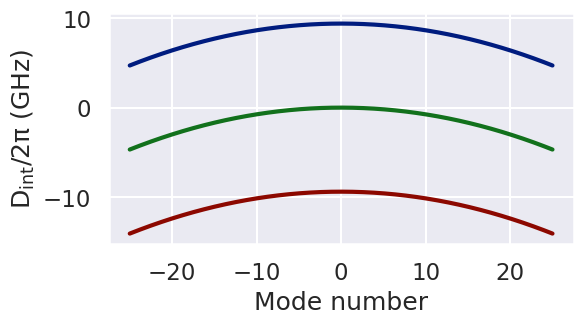

In [138]:
f, ax = plt.subplots(figsize=(6,3))

ax.plot(μ_vec, ωS  - d1*μ_vec, color="C3", lw=3)
ax.plot(μ_vec, ωC  - d1*μ_vec, color="C2", lw=3)
ax.plot(μ_vec, ωAS - d1*μ_vec, color="C0", lw=3)


# ax.plot(μ_vec, d1*(μ_vec) + d2/2*(μ_vec)**2 - d1*μ_vec, color="k", linestyle="--", alpha=.8)

#ax.plot(μ_vec, d1*μ_vec + d2/2*(μ_vec)**2 - d1*μ_vec, color="k", linestyle="--", alpha=.8)

ax.set_xlabel('Mode number')
ax.set_ylabel('D$_{\\text{int}}$/2π (GHz)')

# ax.set_ylim(-10, 10)

f.savefig(figurepath + "Theoretical_Dispersion_Symmetric.svg")

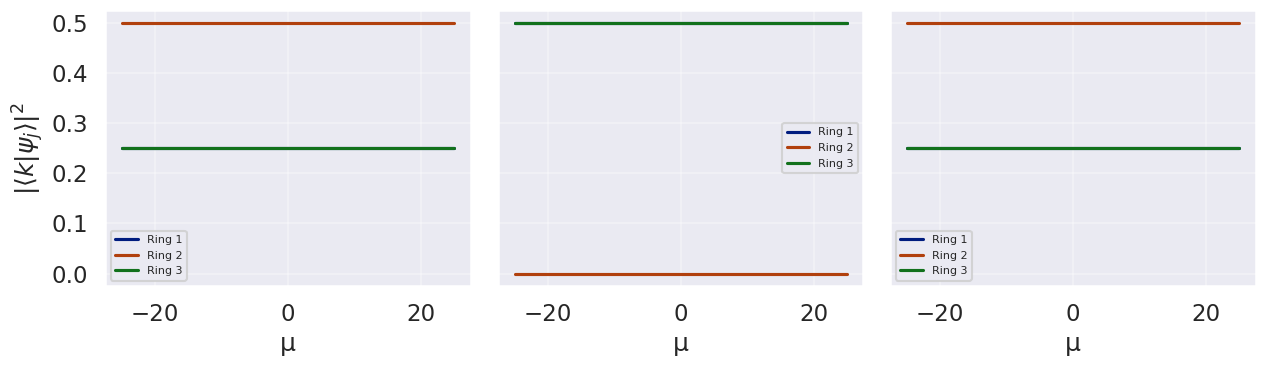

In [125]:
component_labels = ['Ring 1', 'Ring 2', 'Ring 3']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for j, ax in enumerate(axes):
    for k in range(3):
        ax.plot(μ_vec, eigenvec[:, k, j]**2,
                label=component_labels[k], color=f'C{k}')
    #ax.set_title(labels[j])
    ax.set_xlabel('μ')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('$|\\langle k | \\psi_j \\rangle|^2$')
#fig.suptitle('Composição dos autovetores (peso de cada base desacoplada)', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2677752/497587333.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


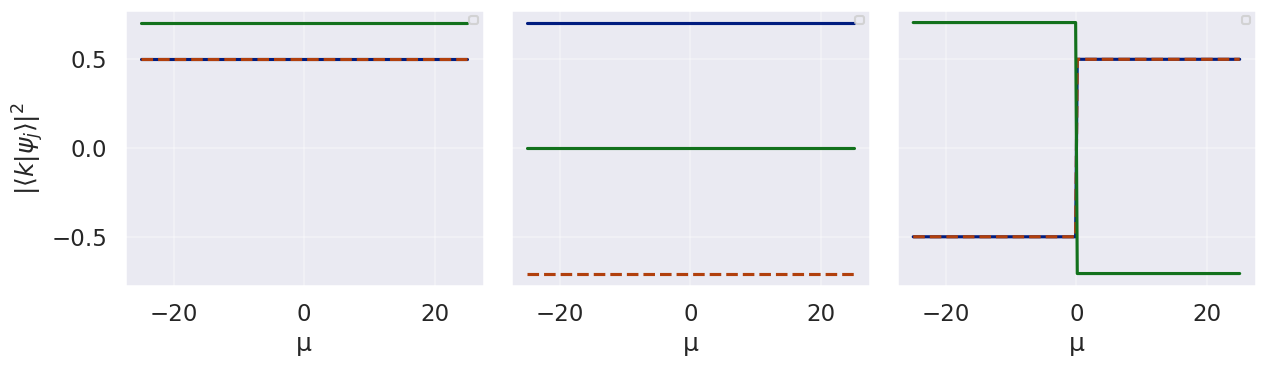

In [126]:
component_labels = ['Ring 1', 'Ring 2', 'Ring 3']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for j, ax in enumerate(axes):
    ax.plot(μ_vec, bS[:, j], ls="-")
    ax.plot(μ_vec, bAS[:, j], ls="--")
    ax.plot(μ_vec, bC[:, j])
    #ax.set_title(labels[j])
    ax.set_xlabel('μ')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('$|\\langle k | \\psi_j \\rangle|^2$')
#fig.suptitle('Composição dos autovetores (peso de cada base desacoplada)', y=1.02)
plt.tight_layout()
plt.show()